In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
from sklearn.manifold import TSNE
import umap
from torchvision import datasets, transforms
from sklearn.datasets import load_iris
from numpy import reshape
import seaborn as sns
import pandas as pd
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import normalized_mutual_info_score, silhouette_score
from sklearn.cluster import KMeans
import csv
import matplotlib.pyplot as plt

/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
## Preparation for similarity method
torch.cuda.is_available()

True

## 1. Data prepocessing

In [4]:
def data_generate(ty):
    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    fashion_mnist_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

    n=40000

    x_train = fashion_mnist_dataset.data[:n].float()
    y_train = fashion_mnist_dataset.targets[:n].float()

    x_train = x_train.view(x_train.shape[0], -1)/255

    # print(f"x_train shape: {x_train.shape}")
    # print(f"y_train shape: {y_train.shape}")

    if ty == 'iid':
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(device)
        x_new = x_train.T
        X = [x_new[:, i*4000:(i+1)*4000].to(device) for i in range(10)]
    
    if ty == 'noniid':
        x_new = x_train.T

        #--------------------------------------------------------------
        # Initialize a list to hold the data for each label
        label_lists = [[] for _ in range(10)]

        # Separate the data by label
        for i in range(x_train.shape[0]):
            label = int(y_train[i])
            label_lists[label].append(x_train[i])

        # Ensure all elements in each list have the same shape
        for i in range(10):
            label_lists[i] = np.stack(label_lists[i], axis=0) 
            
        # Convert the lists to numpy arrays and then to tensors
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        X = [torch.tensor(np.array(label_list), dtype=torch.float32, device=device) for label_list in label_lists]
        for i in range(10):
            X[i] = X[i].t()

        #---------------------------------------------------------------
        y_mnist_new = []

        for label, tensor in enumerate(X):
            y_mnist_new.extend([label] * tensor.shape[1])

        y_train = np.array(y_mnist_new)

    # for i in X:
    #     print(i.shape)
    # print(y_train.shape)

    return X, y_train


## 2. Function defined 

#### Y Approximation
*   n = 70000
*   k = 10
*   ny = 500

In [5]:
def gaussian_kernel(x, y, sigma=1000.0):
    beta = 1.0 / (2.0 * sigma ** 2)
    dist = torch.cdist(x.t(), y.t()) ** 2
    # print(dist.mean())
    kernel = torch.exp(-beta * dist)
    return kernel

def mmd_loss(x, y, sigma_list=[10.0, 20.0, 30.0, 50.0]):

    mmd_list = []
    for sigma in sigma_list:
      xx_kernel = gaussian_kernel(x, x, sigma)
      yy_kernel = gaussian_kernel(y, y, sigma)
      xy_kernel = gaussian_kernel(x, y, sigma)
      mmd = xx_kernel.mean() + yy_kernel.mean() - 2 * xy_kernel.mean()
      mmd_list.append(mmd)
    return max(mmd_list)

# 假设我们有 k 个数据集 X1 到 Xk
k = 10
n = 40000//k
m = 784
ny = 500
batch_size = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

def approximate_Y(X, beta = 0.0, num_epochs = 500):
  
  Y = torch.rand((m, ny), dtype=torch.float32, requires_grad=True, device=device)
  # print(Y)
  learning_rate = 1e-1
  # optimizer = torch.optim.SGD([Y], lr=learning_rate)
  optimizer = torch.optim.Adam([Y], lr=learning_rate)
  # optimizer = torch.optim.RMSprop([Y], lr=learning_rate)

  # 训练循环
  for epoch in range(num_epochs):

      total_loss = 0.0
      optimizer.zero_grad()
      total_grad = None

      for i in range(k):
          Xi = X[i]

          # mini_batch
          dataset = TensorDataset(Xi.t())
          data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

          for batch in data_loader:
            Xi_batch = batch[0].t()
            loss = mmd_loss(Xi_batch, Y)
            loss.backward()
            total_loss += loss.item()

            gradients = Y.grad
            std_grad = torch.std(gradients)
            noise = torch.randn_like(gradients) * std_grad * beta
            noisy_gradients = gradients + noise

            if total_grad is None:
              total_grad = noisy_gradients
            else:
              total_grad += noisy_gradients
            break # only use first mini-batch

          Y.grad.zero_()

      avg_grad = total_grad / k
      total_loss = total_loss / k

      with torch.no_grad():
          Y.grad = avg_grad
          Y.data=torch.clamp(Y.data, min=0, max=1)
          optimizer.step()
      if epoch== num_epochs-1:
          print('Epoch finished')
  return Y

cuda


#### TSNE result

In [6]:
# def calculate_overlap_ratio(high_dim_data, low_dim_data, k):
#     """
#     high_dim_data: torch data (40000*784)
#     low_dim_data: z(40000*2)
#     """
#     high_dim_data = high_dim_data.cpu().detach().numpy()

#     # 在高维空间中找到每个点的 k 近邻
#     nn_high = NearestNeighbors(n_neighbors=k+1).fit(high_dim_data)
#     distances_high, indices_high = nn_high.kneighbors(high_dim_data)
    
#     # 在低维空间中找到每个点的 k 近邻
#     nn_low = NearestNeighbors(n_neighbors=k+1).fit(low_dim_data)
#     distances_low, indices_low = nn_low.kneighbors(low_dim_data)
    
#     overlap_ratios = []
    
#     # 对于每个点，计算两个集合的重叠比例
#     for i in range(len(high_dim_data)):
#         A = set(indices_high[i][1:])  # 跳过自身
#         B = set(indices_low[i][1:])   # 跳过自身
#         overlap = len(A.intersection(B)) / k
#         overlap_ratios.append(overlap)
    
#     return np.mean(overlap_ratios)

In [7]:
def vis_res():
  # TODO
  # six pictures one time (correct, ftsne, ftsne-beta = 1 ...)

  fig, axes = plt.subplots(2, 5, figsize=(27, 10))

  # iid -------------------------------------------------------------------------------------
  X, y_train = data_generate('iid')
  X_cat = torch.cat(X, dim=1)
  #-----------------
  cols = X_cat.size(1)
  torch.manual_seed(42)
  perm = torch.randperm(cols)
  shuffled_X_cat = X_cat[:, perm]
  y_train = y_train[perm]
  # ----------------------------------------------------------------------------

  # correct
  distance = torch.cdist(shuffled_X_cat.t(), shuffled_X_cat.t()).detach().cpu().numpy()
  tsne = TSNE(n_components=2, verbose=0, metric="precomputed", init='random', random_state=142)
  z = tsne.fit_transform(distance)

  df = pd.DataFrame()
  df["y"] = y_train
  df["comp-1"] = z[:,0]
  df["comp-2"] = z[:,1]

  sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                    palette=sns.color_palette("hls", 10),
                    data=df, ax=axes[0, 0]).set(title="FMNIST data tSNE projection")
  print('finish...')

  # ftsne
  torch.manual_seed(42)
  Y = approximate_Y(X, beta = 0.0, num_epochs=500)
  distance = estimate_x_dist(shuffled_X_cat, Y).cpu().detach().numpy()
  tsne = TSNE(n_components=2, verbose=0, metric="precomputed", init='random', random_state=142)
  z = tsne.fit_transform(distance)

  df = pd.DataFrame()
  df["y"] = y_train
  df["comp-1"] = z[:,0]
  df["comp-2"] = z[:,1]

  sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                    palette=sns.color_palette("hls", 10),
                    data=df, ax=axes[0, 1]).set(title="FMNIST data Fed-tSNE projection (IID)")
  print('finish...')

  # ftsne+
  torch.manual_seed(42)
  Y = approximate_Y(X, beta = 1.0, num_epochs=500)
  distance = estimate_x_dist(shuffled_X_cat, Y).cpu().detach().numpy()
  tsne = TSNE(n_components=2, verbose=0, metric="precomputed", init='random', random_state=142)
  z = tsne.fit_transform(distance)

  df = pd.DataFrame()
  df["y"] = y_train
  df["comp-1"] = z[:,0]
  df["comp-2"] = z[:,1]

  sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                    palette=sns.color_palette("hls", 10),
                    data=df, ax=axes[0, 2]).set(title="FMNIST data Fed-tSNE+ projection (IID)")
  print('finish...')

  # umap
  distance = torch.cdist(shuffled_X_cat.t(), shuffled_X_cat.t()).detach().cpu().numpy()
  reducer = umap.UMAP(n_components=2, metric='precomputed', init='random', random_state=142)
  z = reducer.fit_transform(distance)

  df = pd.DataFrame()
  df["y"] = y_train
  df["comp-1"] = z[:,0]
  df["comp-2"] = z[:,1]

  sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                    palette=sns.color_palette("hls", 10),
                    data=df, ax=axes[1, 0]).set(title="FMNIST data UMAP projection")
  print('finish...')

  # fumap
  torch.manual_seed(42)
  Y = approximate_Y(X, beta = 0.0, num_epochs=500)
  distance = estimate_x_dist(shuffled_X_cat, Y).cpu().detach().numpy()
  reducer = umap.UMAP(n_components=2, metric='precomputed', init='random', random_state=142)
  z = reducer.fit_transform(distance)

  df = pd.DataFrame()
  df["y"] = y_train
  df["comp-1"] = z[:,0]
  df["comp-2"] = z[:,1]

  sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                    palette=sns.color_palette("hls", 10),
                    data=df, ax=axes[1, 1]).set(title="FMNIST data Fed-UMAP projection (IID)")
  print('finish...')

  # fumap+
  torch.manual_seed(42)
  Y = approximate_Y(X, beta = 1.0, num_epochs=500)
  distance = estimate_x_dist(shuffled_X_cat, Y).cpu().detach().numpy()
  reducer = umap.UMAP(n_components=2, metric='precomputed', init='random', random_state=142)
  z = reducer.fit_transform(distance)

  df = pd.DataFrame()
  df["y"] = y_train
  df["comp-1"] = z[:,0]
  df["comp-2"] = z[:,1]

  sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                    palette=sns.color_palette("hls", 10),
                    data=df, ax=axes[1, 2]).set(title="FMNIST data Fed-UMAP+ projection (IID)")
  print('finish...')


  # noniid -------------------------------------------------------------------------------------
  X, y_train = data_generate('noniid')
  X_cat = torch.cat(X, dim=1)
  #-----------------
  cols = X_cat.size(1)
  torch.manual_seed(42)
  perm = torch.randperm(cols)
  shuffled_X_cat = X_cat[:, perm]
  y_train = y_train[perm]
  # ----------------------------------------------------------------------------
  
  # ftsne
  torch.manual_seed(42)
  Y = approximate_Y(X, beta = 0.0, num_epochs=500)
  distance = estimate_x_dist(shuffled_X_cat, Y).cpu().detach().numpy()
  tsne = TSNE(n_components=2, verbose=0, metric="precomputed", init='random', random_state=142)
  z = tsne.fit_transform(distance)

  df = pd.DataFrame()
  df["y"] = y_train
  df["comp-1"] = z[:,0]
  df["comp-2"] = z[:,1]

  sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                    palette=sns.color_palette("hls", 10),
                    data=df, ax=axes[0, 3]).set(title="FMNIST data Fed-tSNE projection (non-IID)")
  print('finish...')

  # ftsne+
  torch.manual_seed(42)
  Y = approximate_Y(X, beta = 1.0, num_epochs=500)
  distance = estimate_x_dist(shuffled_X_cat, Y).cpu().detach().numpy()
  tsne = TSNE(n_components=2, verbose=0, metric="precomputed", init='random', random_state=142)
  z = tsne.fit_transform(distance)

  df = pd.DataFrame()
  df["y"] = y_train
  df["comp-1"] = z[:,0]
  df["comp-2"] = z[:,1]

  sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                    palette=sns.color_palette("hls", 10),
                    data=df, ax=axes[0, 4]).set(title="FMNIST data Fed-tSNE+ projection (non-IID)")
  print('finish...')

  # fumap
  torch.manual_seed(42)
  Y = approximate_Y(X, beta = 0.0, num_epochs=500)
  distance = estimate_x_dist(shuffled_X_cat, Y).cpu().detach().numpy()
  reducer = umap.UMAP(n_components=2, metric='precomputed', init='random', random_state=142)
  z = reducer.fit_transform(distance)

  df = pd.DataFrame()
  df["y"] = y_train
  df["comp-1"] = z[:,0]
  df["comp-2"] = z[:,1]

  sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                    palette=sns.color_palette("hls", 10),
                    data=df, ax=axes[1, 3]).set(title="FMNIST data Fed-UMAP projection (non-IID)")
  print('finish...')

  # fumap+
  torch.manual_seed(42)
  Y = approximate_Y(X, beta = 1.0, num_epochs=500)
  distance = estimate_x_dist(shuffled_X_cat, Y).cpu().detach().numpy()
  reducer = umap.UMAP(n_components=2, metric='precomputed', init='random', random_state=142)
  z = reducer.fit_transform(distance)

  df = pd.DataFrame()
  df["y"] = y_train
  df["comp-1"] = z[:,0]
  df["comp-2"] = z[:,1]

  sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                    palette=sns.color_palette("hls", 10),
                    data=df, ax=axes[1, 4]).set(title="FMNIST data Fed-UMAP+ projection (non-IID)")
  print('finish...')

In [8]:
def estimate_x_dist(shuffled_X_cat, Y):
  '''
  shuffled_X_cat
  Y: learned dist
  '''
  B = torch.cdist(Y.t(), shuffled_X_cat.t())
  A = torch.cdist(Y.t(), Y.t())
  # A = A + torch.eye(A.shape[0], device = device)*1e-5
  # B = Y.t() @ X_cat
  # A = Y.t() @ Y
  res = B.t() @ torch.linalg.inv(A) @ B
  res[torch.arange(res.size(0)), torch.arange(res.size(1))] = 0
  return res

## 3. Experiments

cuda
finish...
Epoch finished
finish...
Epoch finished
finish...


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/umap/umap_.py:1858: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


finish...
Epoch finished


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/umap/umap_.py:1858: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


finish...
Epoch finished


...

finish...
Epoch finished
finish...
Epoch finished
finish...
Epoch finished


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/umap/umap_.py:1858: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


finish...
Epoch finished


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/umap/umap_.py:1858: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


finish...


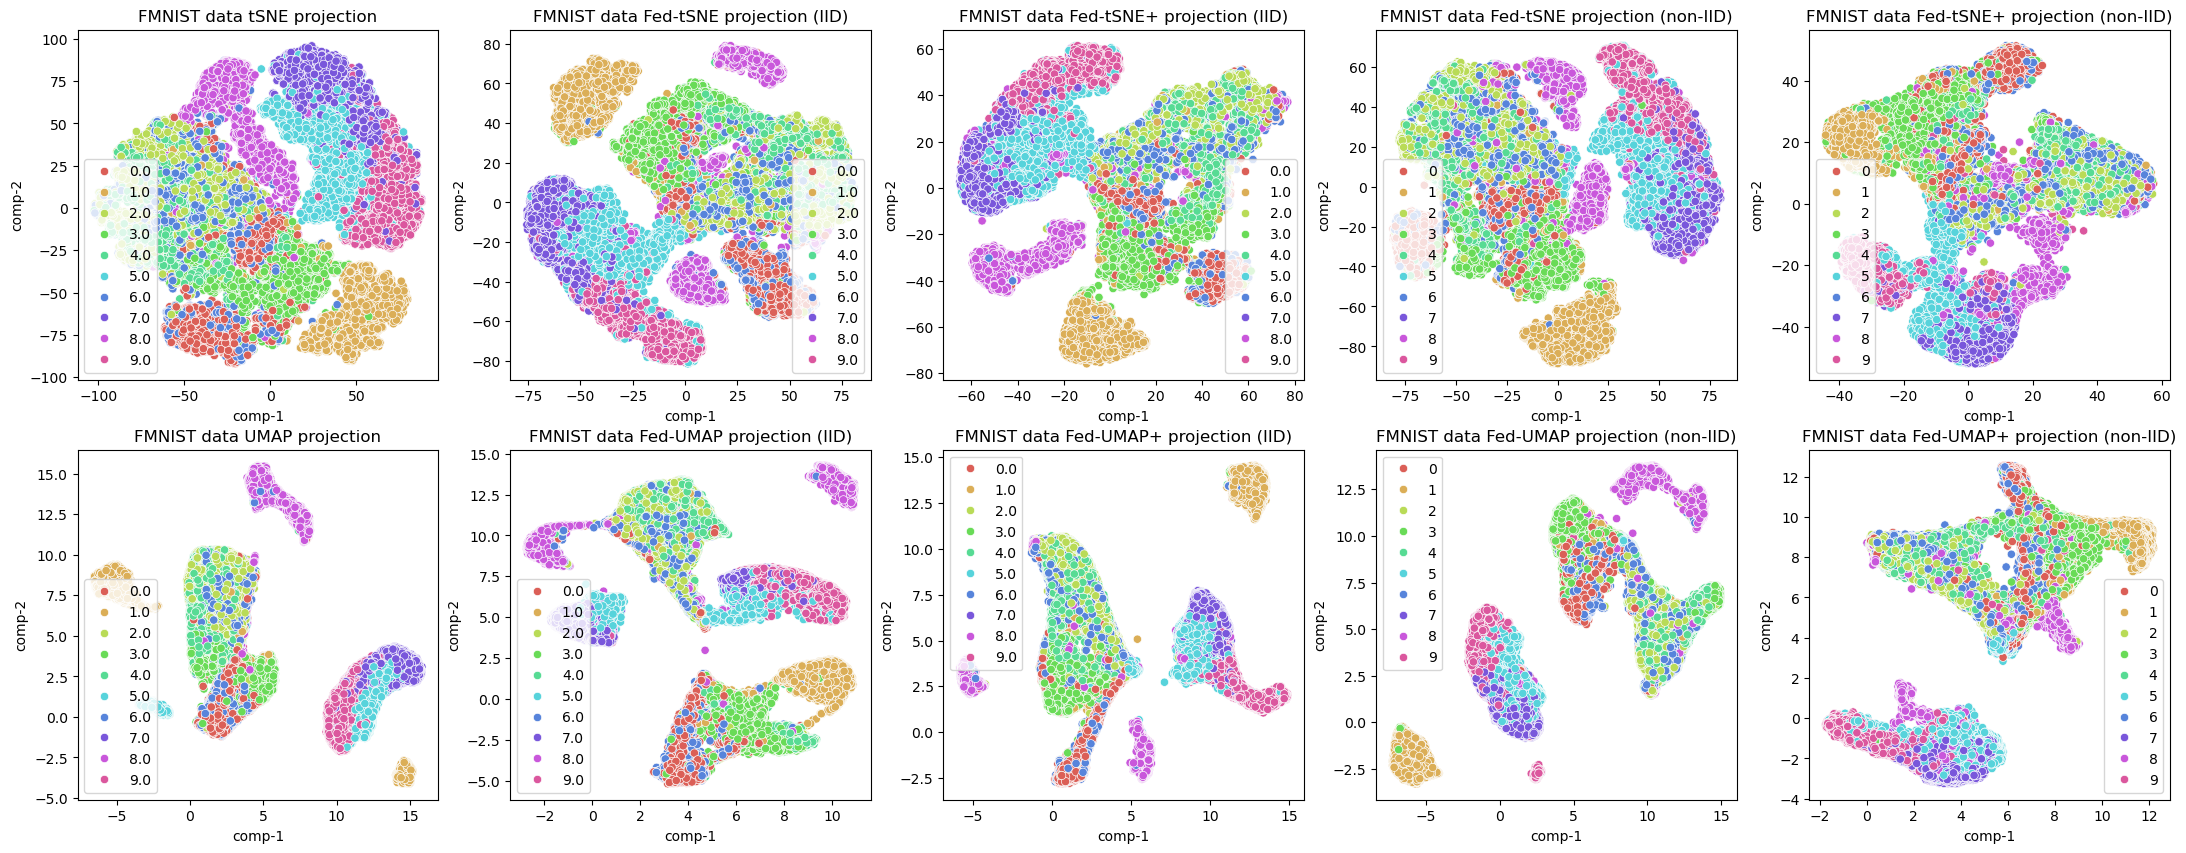

In [9]:
vis_res()